# K-mer Analysis

**Description:**
This notebook analyzes RNA sequences to calculate the frequency of specific subsequences ($k$-mers). It reads a custom FASTA-like format containing sequence and structure information, extracts $k$-mers (e.g., 6-mers, 7-mers), and visualizes the top 10 most frequent motifs.

**Table of Contents:**
1.  Imports & Setup
2.  Data Loading Module
3.  K-mer Analysis Module
4.  Visualization Module
5.  Main Execution Loop

## 1. Imports & Setup

In [1]:
import random
import re
import os
from collections import Counter
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Global Plotting Configuration
# Note: Ensure 'Calibri' is installed on your system, otherwise matplotlib may fallback to a default font.
rcParams['pdf.fonttype'] = 42       # Output TrueType fonts for editable PDFs
rcParams['font.family'] = 'Calibri' # Set default font family
rcParams['text.usetex'] = False     # Disable external LaTeX rendering for speed

## 2. Data Loading Module

**Input File Format Specification:**
The code expects a `.fa` file where every record consists of exactly **3 lines**:
1.  **Header:** Starts with `>` (e.g., `>seq1`)
2.  **Sequence:** Nucleotide string (A, C, G, T, U, N)
3.  **Structure Scores:** Comma-separated floating point values matching the sequence length.

In [2]:
def read_fasta_with_struct_single(
    path: str,
    label_val: int,
) -> Tuple[List[str], List[str], np.ndarray]:
    """
    Reads a custom FASTA-like file containing headers, sequences, and structure scores.
    
    Validates that the file follows the 3-line block structure:
      Line 1: Header (must start with '>')
      Line 2: Sequence (ACGTUN characters)
      Line 3: Structure scores (comma-separated string)

    Args:
        path (str): The absolute or relative path to the .fa file.
        label_val (int): The label to assign to all entries in this file (e.g., 1 for positive, 0 for negative).

    Returns:
        Tuple containing:
        - sequences (List[str]): A list of raw nucleotide sequence strings.
        - structs (List[str]): A list of raw structure strings (comma-separated).
        - labels (np.ndarray): A float32 array of shape (N, 1) containing the `label_val`.

    Raises:
        ValueError: If line count is not divisible by 3, header is missing '>', 
                    sequence contains invalid chars, or sequence/structure length mismatch.
    """
    sequences: List[str] = []
    structs: List[str] = []

    print(f"Loading data from: {path}")
    
    with open(path, "r") as f:
        # Filter out empty lines to ensure robustness
        lines = [ln.strip() for ln in f if ln.strip()]

    if len(lines) % 3 != 0:
        raise ValueError(f"{path}: Line count ({len(lines)}) is not a multiple of 3. Check file integrity.")

    # Iterate in blocks of 3
    for i in range(0, len(lines), 3):
        hdr, seq, struct_str = lines[i], lines[i+1], lines[i+2]
        
        # Validation 1: Header format
        if not hdr.startswith(">"):
            raise ValueError(f"{path}: Invalid header at line {i+1}. Expected '>', found '{hdr[0]}'")
        
        # Validation 2: Sequence content (Allowing A, C, G, T, U, N)
        if not re.fullmatch(r"[ACGTUN]+", seq):
            raise ValueError(f"{path}: Invalid sequence characters at block starting line {i+1}")

        # Validation 3: Length consistency
        arr_len = len(struct_str.split(","))
        if len(seq) != arr_len:
            raise ValueError(f"{path}: Mismatch at line {i+1}. Seq len={len(seq)}, Struct len={arr_len}")

        sequences.append(seq)
        structs.append(struct_str)

    # Create label array
    labels = np.full((len(sequences), 1), label_val, dtype=np.float32)
    
    return sequences, structs, labels


def read_fasta(
    pos_path: str
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Wrapper function to read a positive sample file and convert lists to NumPy arrays.

    Args:
        pos_path (str): Path to the positive class .fa file.

    Returns:
        Tuple containing:
        - sequences (np.ndarray): Array of sequence strings (dtype=object).
        - structs (np.ndarray): Array of structure strings (dtype=object).
        - labels (np.ndarray): Array of labels (dtype=float32).
    """
    # Parse the file
    seq_pos, struct_pos, label_pos = read_fasta_with_struct_single(pos_path, 1)

    # Convert to Numpy arrays for downstream compatibility
    sequences = np.array(seq_pos, dtype=object)
    structs   = np.array(struct_pos, dtype=object)
    labels    = np.vstack([label_pos]).astype(np.float32)

    return sequences, structs, labels

## 3. K-mer Analysis Module

In [3]:
def seq2kmer_freq(seq: str, k: int) -> Counter:
    """
    Extracts all k-mers from a single sequence using a sliding window.

    Args:
        seq (str): The input nucleotide sequence (e.g., "ACGT...").
        k (int): The length of the k-mer (e.g., 6).

    Returns:
        Counter: A dictionary-like object mapping k-mer strings to their counts in this sequence.
    """
    # List comprehension for sliding window
    kmers = [seq[x : x + k] for x in range(len(seq) + 1 - k)]
    return Counter(kmers)


def seq2kmer_freqcount(sequences: np.ndarray, k: int) -> Dict[str, int]:
    """
    Aggregates k-mer frequencies across a whole dataset of sequences.

    Args:
        sequences (np.ndarray or List[str]): Collection of sequences.
        k (int): The length of the k-mer.

    Returns:
        Dict[str, int]: A dictionary mapping k-mers to their total count across all sequences.
    """
    total_kmer_freqs = Counter()
    
    for seq in sequences:
        # Update global counter with counts from the current sequence
        total_kmer_freqs += seq2kmer_freq(seq, k)
        
    # Convert Counter to a standard dict for output
    return dict(total_kmer_freqs)

## 4. Visualization Module

In [4]:
def kmer_freq_plot(kmer_freqs: Dict[str, int], k: int, RBPname: str, bar_color: str = "#e07a5f"):
    """
    Visualizes the Top 10 most frequent k-mers using a horizontal bar chart.
    
    Performs data cleaning (T -> U conversion) to simulate RNA context.

    Args:
        kmer_freqs (Dict[str, int]): Dictionary of k-mer counts.
        k (int): The k-value used (for labeling axes).
        RBPname (str): The name of the RBP or file path (used for the plot title).
    """
    # Convert dictionary to DataFrame for easier sorting/manipulation
    df = pd.DataFrame(list(kmer_freqs.items()), columns=['kmer', 'counts'])

    if df.empty:
        print(f"Warning: No {k}-mers found. Skipping plot.")
        return

    # Select the top 10 k-mers by count
    tophigh_kmers = df.nlargest(10, 'counts').copy()

    # Label for potential future stacking (currently unused logic but preserved)
    tophigh_kmers['label'] = 'top 10%'

    # Biological Context: Convert DNA 'T' to RNA 'U' for visualization
    tophigh_kmers['kmer'] = tophigh_kmers['kmer'].str.replace('T', 'U')

    # Setup Plot
    plt.figure(figsize=(4, 5)) # Slightly adjusted size for readability
    
    # Define a color palette
    # Using a single color for clarity, or map specific colors if needed
    colors = [bar_color] * len(tophigh_kmers)

    # Create Horizontal Bar Plot
    tophigh_kmers = tophigh_kmers.sort_values(by='counts', ascending=False) # Sort so largest is at bottom of barh
    
    plt.barh(tophigh_kmers['kmer'], tophigh_kmers['counts'], color=colors, alpha=1.0, height=0.6)

    # Labeling
    plt.ylabel(f'{k}-mers')
    plt.xlabel('Frequency Counts')
    
    # Clean up file path for title (handle Windows backslashes or Linux forward slashes)
    clean_title = os.path.basename(RBPname) 
    plt.title(f"RBP: {clean_title} (k={k})")
    
    plt.tight_layout()
    plt.show()

## 5. Main Execution Loop
```{note}
Please download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset/`).
You need to set `DATASET_DIR` according to your own directory structure as below.
```

Loading data from: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/dataset/NONO_K562_pos.fa

Successfully loaded 5000 sequences from NONO_K562_pos
Processing k=8...


findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.


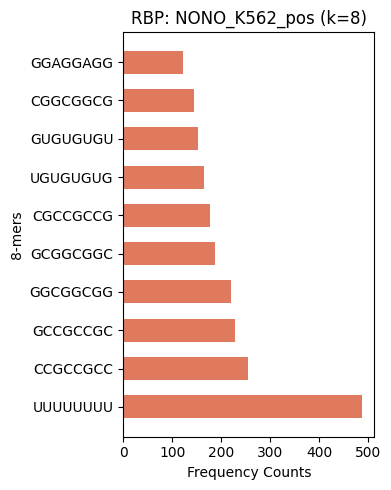

Loading data from: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/dataset/FTO_K562_pos.fa

Successfully loaded 5000 sequences from FTO_K562_pos
Processing k=8...


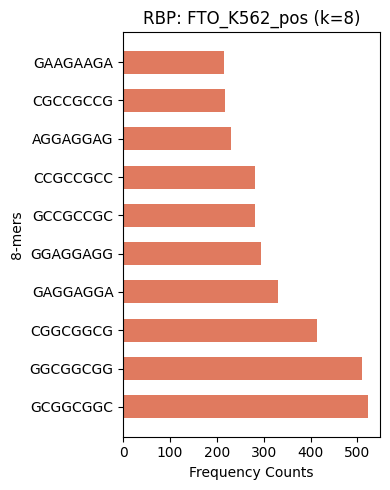

Loading data from: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/dataset/NONO_K562_neg.fa

Successfully loaded 10002 sequences from NONO_K562_neg
Processing k=8...


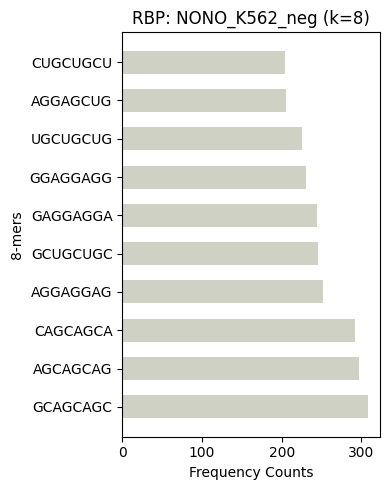

Loading data from: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/dataset/FTO_K562_neg.fa

Successfully loaded 10000 sequences from FTO_K562_neg
Processing k=8...


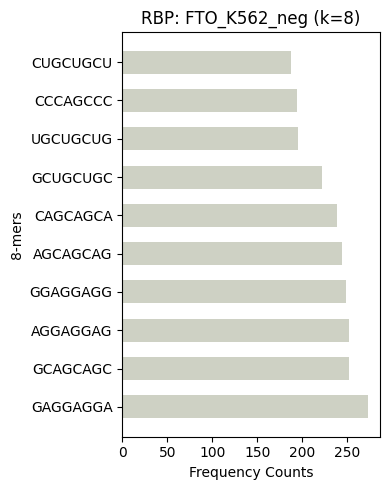

In [ ]:
# Configuration
# ---------------------------------------------------------
# Define the dataset directory. 
DATASET_DIR = "../../dataset"
TARGET_FILES = ["NONO_K562_pos","FTO_K562_pos"]
TARGET_FILES = TARGET_FILES + [x.replace("_pos", "_neg") for x in TARGET_FILES]
K_VALUES = [8]

# Execution
# ---------------------------------------------------------
for rbp_file_base in TARGET_FILES:
    # Construct full path
    full_path = os.path.join(DATASET_DIR, rbp_file_base + ".fa")
    
    # Check if file exists before trying to read
    if not os.path.exists(full_path):
        print(f"Error: File not found at {full_path}")
        print("Tip: Run the 'Dummy Data Generation' cell if you don't have the real data.")
        continue

    # 1. Read Data
    try:
        sequences, _, _ = read_fasta(full_path)
        print(f"\nSuccessfully loaded {len(sequences)} sequences from {rbp_file_base}")
    except Exception as e:
        print(f"Failed to read file: {e}")
        continue

    # 2. Iterate through k-values
    for k in K_VALUES:
        print(f"Processing k={k}...")
        
        # Calculate Frequencies
        kmer_freqs = seq2kmer_freqcount(sequences, k)
        
        # Optional: Print raw dictionary (can be verbose for large k)
        # print(kmer_freqs) 

        # Plot
        bar_color = "#ced1c4" if rbp_file_base.endswith("_neg") else "#e07a5f"
        kmer_freq_plot(kmer_freqs, k, rbp_file_base, bar_color=bar_color)